Data shape: (600, 2)


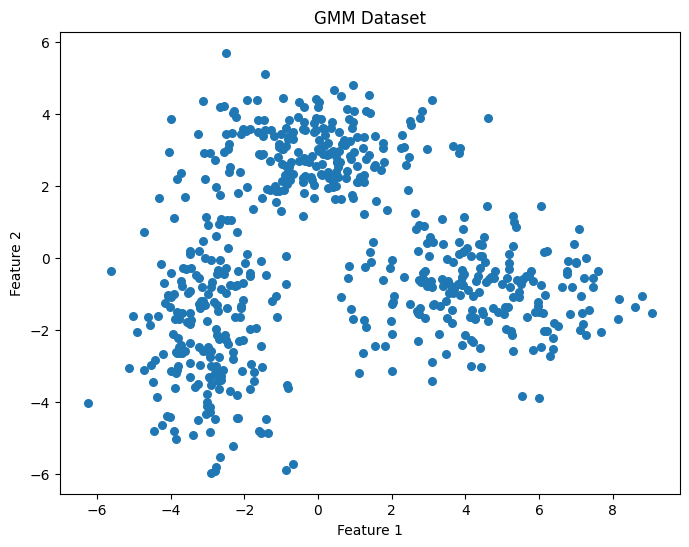


First 20 cluster predictions:
[2 0 1 0 1 2 1 0 0 0 1 2 0 0 2 1 2 2 2 2]

Responsibilities for first 5 points:
[[2.13187752e-04 1.12299329e-08 9.99786801e-01]
 [9.99983945e-01 1.60550008e-05 2.74619128e-12]
 [8.74879222e-06 5.77319256e-01 4.22671996e-01]
 [9.99999592e-01 4.08250087e-07 4.44900588e-18]
 [2.74418886e-06 9.99917563e-01 7.96923252e-05]]

Sum of responsibilities for first point:
1.0000000000000002


/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


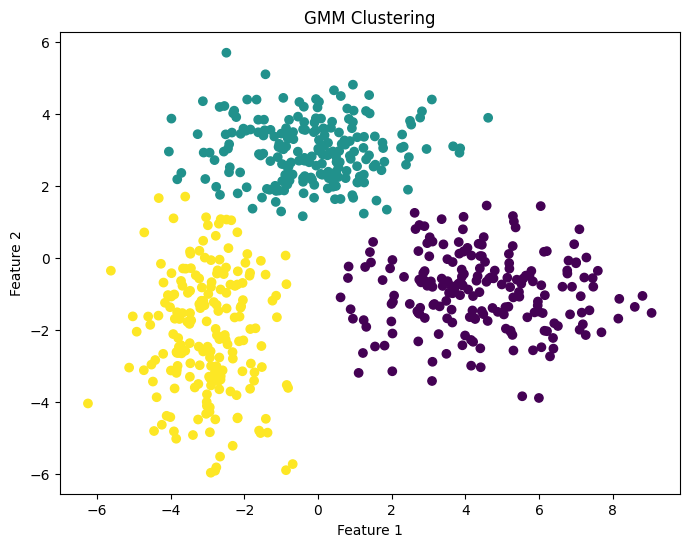

/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.1


GMM Means:
[[ 4.39939511 -0.94379807]
 [-0.16642493  2.97117126]
 [-3.00076775 -2.0575112 ]]

GMM Weights:
[0.33300061 0.34383593 0.32316346]

GMM Covariances:
[[[ 3.34517711 -0.09660103]
  [-0.09660103  1.11349911]]

 [[ 2.45580533 -0.01136199]
  [-0.01136199  0.71219913]]

 [[ 0.92831214 -0.0730293 ]
  [-0.0730293   3.11430078]]]


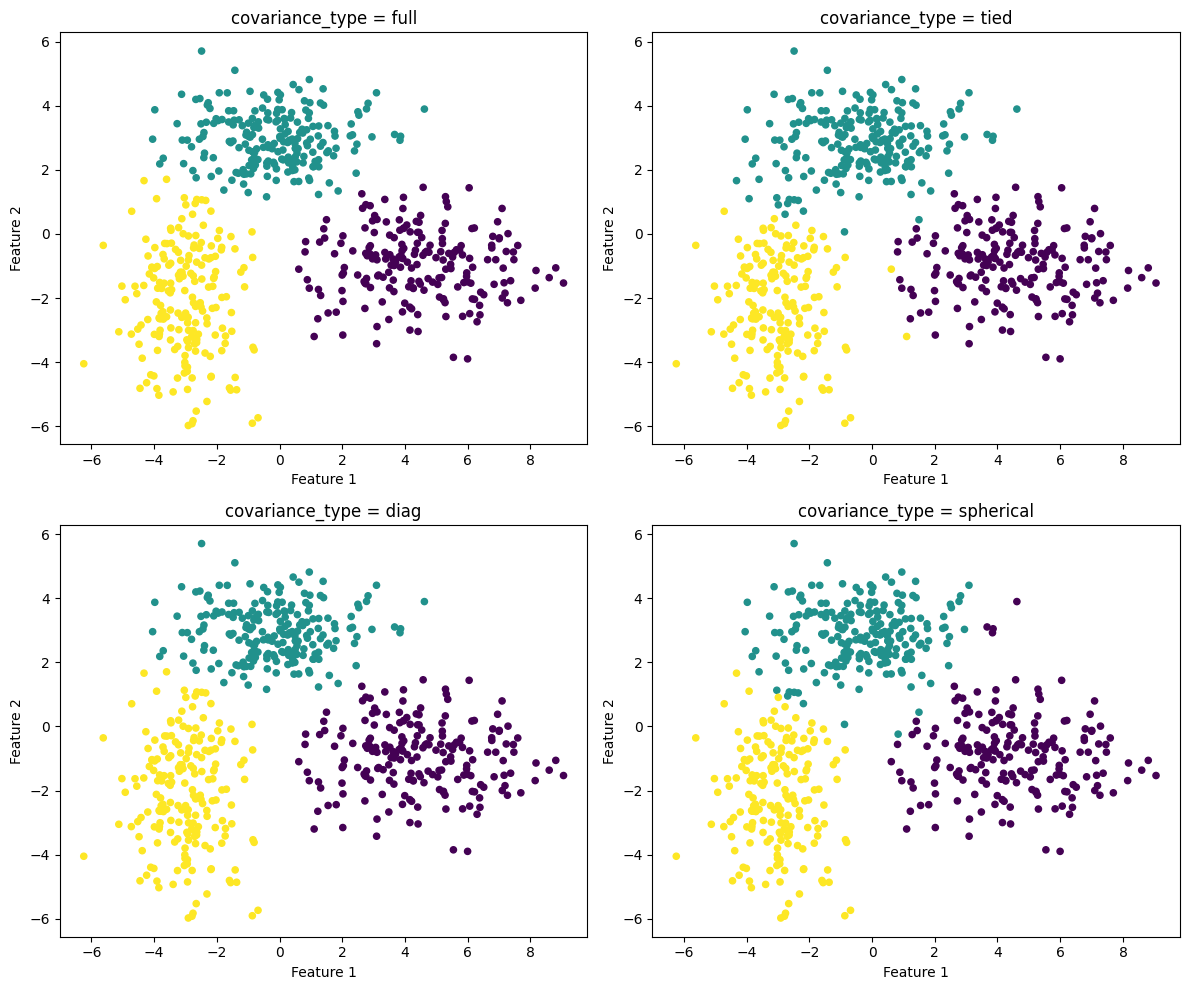

/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.1

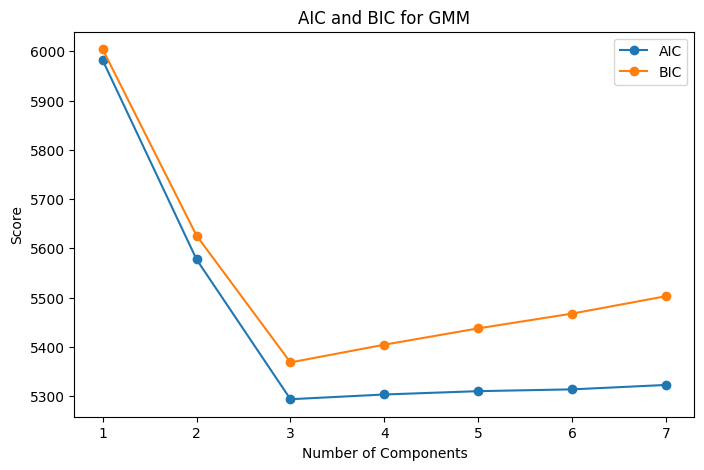


Best number of components according to BIC: 3

Final GMM labels:
[2 0 1 0 1 2 1 0 0 0 1 2 0 0 2 1 2 2 2 2]

Log probability of first 10 points:
[-3.52600059 -3.72778177 -5.80377095 -3.87227596 -3.64872717 -3.89786462
 -3.85321633 -4.70584846 -5.22049765 -3.96536992]


/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vivek-18890/Python/.venv310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [1]:
# ============================================================
# GMM — GAUSSIAN MIXTURE MODEL 🟡
# ============================================================
#
# DEPTH:
#   🟡 Medium
#
# No scratch implementation required.
#
# Learn:
#   1. Why GMM?
#   2. Intuition
#   3. Gaussian distribution
#   4. Mixture model
#   5. Soft clustering
#   6. EM algorithm
#   7. E-step
#   8. M-step
#   9. Covariance types
#  10. sklearn implementation
#  11. Important parameters
#  12. Experiments
#  13. GMM vs K-Means
#  14. Interview questions
#  15. 30-second explanation
#  16. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

from sklearn.mixture import GaussianMixture

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)


# ============================================================
# 2. WHY GMM?
# ============================================================
#
# Suppose we have data:
#
#
#       ● ● ●
#      ● ● ●
#
#
#                     ○ ○ ○
#                    ○ ○ ○
#
#
# We want to find groups without labels.
#
# K-Means does:
#
#     Point → Cluster 1
#
# or:
#
#     Point → Cluster 2
#
# This is HARD assignment.
#
#
# GMM does:
#
#     Point → 80% Cluster 1
#             20% Cluster 2
#
# This is SOFT assignment.
#
# ============================================================


# ============================================================
# 3. CORE INTUITION ⭐⭐⭐
# ============================================================
#
# GMM assumes:
#
# The data was generated from several Gaussian distributions.
#
#
# Example:
#
#
#              Gaussian 1
#                  ↓
#             ● ● ● ●
#           ● ● ● ● ●
#
#
#                         Gaussian 2
#                              ↓
#                         ○ ○ ○ ○
#                       ○ ○ ○ ○ ○
#
#
# The complete dataset is a MIXTURE of Gaussian distributions.
#
#
# Therefore:
#
#     Gaussian 1
#          +
#     Gaussian 2
#          +
#     Gaussian 3
#          ↓
#     Mixture Model
#
# ============================================================


# ============================================================
# 4. WHAT IS A GAUSSIAN?
# ============================================================
#
# A Gaussian distribution is commonly called a Normal
# distribution.
#
#
# 1D:
#
#                  /\
#                /    \
#              /        \
#            /            \
#     -------|-------------|-------
#
#
# It is described by:
#
#     Mean (μ)
#     Variance (σ²)
#
#
# In multiple dimensions:
#
#     Mean vector
#     Covariance matrix
#
#
# GMM uses multiple Gaussian distributions.
#
# ============================================================


# ============================================================
# 5. MIXTURE MODEL ⭐⭐⭐
# ============================================================
#
# Suppose we have K Gaussian distributions.
#
#
# P(X) =
#
#     π1 P(X | Gaussian 1)
#   + π2 P(X | Gaussian 2)
#   + ...
#   + πK P(X | Gaussian K)
#
#
# where:
#
#     πk = mixing coefficient
#
#
# Mixing coefficients satisfy:
#
#     π1 + π2 + ... + πK = 1
#
#
# Example:
#
#     Gaussian 1 = 0.5
#     Gaussian 2 = 0.3
#     Gaussian 3 = 0.2
#
#     Total = 1.0
#
# ============================================================


# ============================================================
# 6. SOFT CLUSTERING ⭐⭐⭐
# ============================================================
#
# This is one of the most important GMM concepts.
#
#
# K-Means:
#
#     Point A → Cluster 1
#
#
# GMM:
#
#     Point A:
#
#         Cluster 1 → 0.85
#         Cluster 2 → 0.10
#         Cluster 3 → 0.05
#
#
# These values are called RESPONSIBILITIES.
#
#
# They represent how strongly each Gaussian is responsible
# for explaining a particular point.
#
# ============================================================


# ============================================================
# 7. RESPONSIBILITY ⭐⭐⭐
# ============================================================
#
# For point x_i and Gaussian k:
#
#
# γ_ik =
#
# π_k * N(x_i | μ_k, Σ_k)
# ------------------------
# Σ_j π_j * N(x_i | μ_j, Σ_j)
#
#
# Where:
#
#     γ_ik = responsibility
#     π_k  = mixture weight
#     μ_k  = mean
#     Σ_k  = covariance
#
#
# Important:
#
# For every point:
#
#     sum of responsibilities = 1
#
#
# Example:
#
# Point X:
#
#     G1 → 0.7
#     G2 → 0.2
#     G3 → 0.1
#
#     Total = 1.0
#
# ============================================================


# ============================================================
# 8. HOW DOES GMM LEARN?
# ============================================================
#
# GMM commonly uses:
#
#     EM = Expectation-Maximization
#
#
# EM repeatedly performs:
#
#     E-step
#     M-step
#
#
# Until the model converges.
#
# ============================================================


# ============================================================
# 9. EM ALGORITHM ⭐⭐⭐
# ============================================================
#
#
#                 Initialize parameters
#                         │
#                         ▼
#                      E-STEP
#                         │
#                         ▼
#                 Calculate responsibilities
#                         │
#                         ▼
#                      M-STEP
#                         │
#                         ▼
#                Update means/covariances/
#                mixture weights
#                         │
#                         ▼
#                    Convergence?
#                     /          \
#                   NO            YES
#                   │               │
#                   └───> E-step   ▼
#                              Final Model
#
# ============================================================


# ============================================================
# 10. E-STEP ⭐⭐⭐
# ============================================================
#
# E = Expectation
#
# We assume the current Gaussian parameters are correct.
#
# Then ask:
#
#     "How much is each Gaussian responsible for each point?"
#
#
# Calculate:
#
#     responsibilities
#
#
# Example:
#
# Point X:
#
#     Gaussian 1 → 0.8
#     Gaussian 2 → 0.2
#
#
# These responsibilities are used in the next step.
#
# ============================================================


# ============================================================
# 11. M-STEP ⭐⭐⭐
# ============================================================
#
# M = Maximization
#
# Now use the responsibilities to update the Gaussian
# parameters.
#
#
# Update:
#
#     Mean
#     Covariance
#     Mixing coefficient
#
#
# Intuition:
#
# E-step:
#
#     "Who is responsible?"
#
#
# M-step:
#
#     "Update each Gaussian using those responsibilities."
#
# ============================================================


# ============================================================
# 12. SIMPLE EM EXAMPLE
# ============================================================
#
# Suppose:
#
# Point A:
#
#     G1 = 0.9
#     G2 = 0.1
#
# Point B:
#
#     G1 = 0.7
#     G2 = 0.3
#
# Point C:
#
#     G1 = 0.2
#     G2 = 0.8
#
#
# During M-step:
#
# G1 gets more influence from:
#
#     A and B
#
#
# G2 gets more influence from:
#
#     C
#
#
# Then update:
#
#     means
#     covariances
#     weights
#
#
# Repeat until changes become small.
#
# ============================================================


# ============================================================
# 13. CREATE DATA
# ============================================================

X, true_labels = make_blobs(
    n_samples=600,
    centers=[
        [-3, -2],
        [0, 3],
        [4, -1]
    ],
    cluster_std=[
        [1.0, 2.0],
        [1.5, 0.8],
        [2.0, 1.0]
    ],
    random_state=42
)

print("Data shape:", X.shape)


# ============================================================
# 14. VISUALIZE DATA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=30
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "GMM Dataset"
)

plt.show()


# ============================================================
# 15. BASIC GMM
# ============================================================

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X)


# ============================================================
# 16. HARD CLUSTER PREDICTION
# ============================================================
#
# predict() returns the most likely component.
#
# Example:
#
#     Point → Component 0
#
# ============================================================

labels = gmm.predict(X)

print(
    "\nFirst 20 cluster predictions:"
)

print(
    labels[:20]
)


# ============================================================
# 17. SOFT CLUSTERING ⭐⭐⭐
# ============================================================
#
# predict_proba() gives responsibilities.
#
# Each row:
#
#     Probability of belonging to each Gaussian.
# ============================================================

responsibilities = gmm.predict_proba(X)

print(
    "\nResponsibilities for first 5 points:"
)

print(
    responsibilities[:5]
)

print(
    "\nSum of responsibilities for first point:"
)

print(
    responsibilities[0].sum()
)


# ============================================================
# 18. VISUALIZE GMM CLUSTERS
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "GMM Clustering"
)

plt.show()


# ============================================================
# 19. GMM PARAMETERS
# ============================================================
#
# GMM learns:
#
#     means_
#     covariances_
#     weights_
#
# ============================================================

print(
    "\nGMM Means:"
)

print(
    gmm.means_
)

print(
    "\nGMM Weights:"
)

print(
    gmm.weights_
)

print(
    "\nGMM Covariances:"
)

print(
    gmm.covariances_
)


# ============================================================
# 20. WHAT ARE MIXTURE WEIGHTS?
# ============================================================
#
# Suppose:
#
#     weights:
#
#     [0.5, 0.3, 0.2]
#
#
# Roughly:
#
#     Gaussian 1 → 50%
#     Gaussian 2 → 30%
#     Gaussian 3 → 20%
#
#
# They always sum to 1.
#
# ============================================================


# ============================================================
# 21. IMPORTANT GMM PARAMETERS
# ============================================================
#
#
# ------------------------------------------------------------
# n_components ⭐⭐⭐
# ------------------------------------------------------------
#
# Number of Gaussian distributions / clusters.
#
# Example:
#
#     n_components=3
#
# means:
#
#     3 Gaussian components.
#
#
# ------------------------------------------------------------
# covariance_type ⭐⭐⭐
# ------------------------------------------------------------
#
# Defines how covariance is represented.
#
# Options:
#
#     "full"
#     "tied"
#     "diag"
#     "spherical"
#
#
# More details below.
#
#
# ------------------------------------------------------------
# max_iter
# ------------------------------------------------------------
#
# Maximum EM iterations.
#
#
# ------------------------------------------------------------
# tol
# ------------------------------------------------------------
#
# Convergence threshold.
#
# Smaller:
#     more precise convergence
#
# Larger:
#     stop earlier
#
#
# ------------------------------------------------------------
# n_init
# ------------------------------------------------------------
#
# Number of initializations.
#
# GMM can converge to different solutions depending on
# initialization.
#
# More initializations:
#
#     potentially better solution
#     more computation
#
#
# ------------------------------------------------------------
# init_params
# ------------------------------------------------------------
#
# Initialization strategy.
#
# Common options include:
#
#     "kmeans"
#     "random"
#
#
# ------------------------------------------------------------
# reg_covar ⭐⭐
# ------------------------------------------------------------
#
# Adds a small value to the diagonal of covariance matrices.
#
# Helps prevent singular covariance matrices.
#
#
# ------------------------------------------------------------
# random_state
# ------------------------------------------------------------
#
# Controls randomness.
#
# ============================================================


# ============================================================
# 22. COVARIANCE TYPES ⭐⭐⭐
# ============================================================
#
# This is important for understanding GMM.
#
#
# ------------------------------------------------------------
# 1. full
# ------------------------------------------------------------
#
# Each component gets a complete covariance matrix.
#
#
# Example:
#
#     [ σ1²    cov12 ]
#     [ cov12  σ2²  ]
#
#
# Can model:
#
#     different shapes
#     different orientations
#
#
# Most flexible.
#
#
# ------------------------------------------------------------
# 2. tied
# ------------------------------------------------------------
#
# All components share ONE covariance matrix.
#
#
# Similar covariance structure.
#
#
# ------------------------------------------------------------
# 3. diag
# ------------------------------------------------------------
#
# Each component has a diagonal covariance matrix.
#
# Feature correlations are ignored.
#
#
# Example:
#
#     [ σ1²   0   ]
#     [  0   σ2² ]
#
#
# ------------------------------------------------------------
# 4. spherical
# ------------------------------------------------------------
#
# Each component has a single variance value.
#
# Produces roughly spherical clusters.
#
#
# ============================================================


# ============================================================
# 23. COVARIANCE TYPE VISUAL EXPERIMENT
# ============================================================

covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

plt.figure(figsize=(12, 10))

for i, covariance_type in enumerate(
    covariance_types,
    start=1
):

    model = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=42
    )

    model.fit(X)

    cluster_labels = model.predict(X)

    plt.subplot(
        2,
        2,
        i
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=cluster_labels,
        s=20
    )

    plt.title(
        f"covariance_type = {covariance_type}"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()

plt.show()


# ============================================================
# 24. CHOOSING NUMBER OF COMPONENTS
# ============================================================
#
# GMM requires:
#
#     n_components
#
# But how do we choose it?
#
#
# Common methods:
#
#     AIC
#     BIC
#
# Lower is generally preferred.
#
# ============================================================


# ============================================================
# 25. AIC
# ============================================================
#
# AIC = Akaike Information Criterion
#
# It balances:
#
#     Model fit
#     +
#     Model complexity
#
#
# Lower AIC is generally preferred.
#
# ============================================================


# ============================================================
# 26. BIC ⭐⭐⭐
# ============================================================
#
# BIC = Bayesian Information Criterion
#
# Similar idea:
#
#     Good fit
#     +
#     Penalize complexity
#
#
# Lower BIC is generally preferred.
#
# BIC often applies a stronger complexity penalty than AIC.
#
# ============================================================


# ============================================================
# 27. AIC / BIC EXPERIMENT
# ============================================================

components = range(1, 8)

aic_values = []
bic_values = []

for k in components:

    model = GaussianMixture(
        n_components=k,
        random_state=42
    )

    model.fit(X)

    aic_values.append(
        model.aic(X)
    )

    bic_values.append(
        model.bic(X)
    )


plt.figure(figsize=(8, 5))

plt.plot(
    list(components),
    aic_values,
    marker="o",
    label="AIC"
)

plt.plot(
    list(components),
    bic_values,
    marker="o",
    label="BIC"
)

plt.xlabel("Number of Components")
plt.ylabel("Score")

plt.title(
    "AIC and BIC for GMM"
)

plt.legend()

plt.show()


# ============================================================
# 28. SELECT COMPONENTS USING BIC
# ============================================================

best_k = list(components)[
    np.argmin(bic_values)
]

print(
    "\nBest number of components according to BIC:",
    best_k
)


# ============================================================
# 29. BUILD FINAL GMM
# ============================================================

final_gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=42
)

final_gmm.fit(X)

final_labels = final_gmm.predict(X)

print(
    "\nFinal GMM labels:"
)

print(
    final_labels[:20]
)


# ============================================================
# 30. GMM SCORE
# ============================================================
#
# score_samples() gives log probability density of each point.
#
# This can be useful for:
#
#     anomaly detection
#     density estimation
#
# ============================================================

log_probabilities = final_gmm.score_samples(X)

print(
    "\nLog probability of first 10 points:"
)

print(
    log_probabilities[:10]
)


# ============================================================
# 31. GMM FOR ANOMALY DETECTION ⭐⭐
# ============================================================
#
# GMM estimates:
#
#     probability density
#
# A point with very low probability under the learned
# distribution may be considered unusual.
#
#
# Flow:
#
#     Data
#       ↓
#     Fit GMM
#       ↓
#     Calculate log probability
#       ↓
#     Very low probability
#       ↓
#     Potential anomaly
#
# ============================================================


# ============================================================
# 32. GMM vs K-MEANS ⭐⭐⭐
# ============================================================
#
#
# K-MEANS:
#
#     Hard clustering
#
#     Point:
#         Cluster 1
#
#
# GMM:
#
#     Soft clustering
#
#     Point:
#         Cluster 1 = 0.7
#         Cluster 2 = 0.3
#
#
# ------------------------------------------------------------
#
# K-MEANS:
#
#     Uses distance to centroid.
#
#
# GMM:
#
#     Uses probability density.
#
#
# ------------------------------------------------------------
#
# K-MEANS:
#
#     Assumes roughly spherical clusters.
#
#
# GMM:
#
#     Can model elliptical clusters.
#
#
# ------------------------------------------------------------
#
# K-MEANS:
#
#     Centroids.
#
#
# GMM:
#
#     Mean + covariance + mixture weight.
#
# ============================================================


# ============================================================
# 33. GMM vs K-MEANS TABLE
# ============================================================
#
# | Property          | K-Means             | GMM                |
# |-------------------|---------------------|--------------------|
# | Type              | Unsupervised        | Unsupervised       |
# | Assignment        | Hard                | Soft               |
# | Main object       | Centroid            | Gaussian           |
# | Shape             | Spherical-ish       | Elliptical          |
# | Probability       | No                  | Yes                |
# | Algorithm         | Iterative centroid | EM                 |
# | Covariance        | No                  | Yes                |
# | Density estimate  | No                  | Yes                |
#
# ============================================================


# ============================================================
# 34. GMM vs K-MEANS — SIMPLE EXAMPLE
# ============================================================
#
# Suppose:
#
#       ● ● ●
#      ● ● ●
#       ● ●
#
#                     ○
#                   ○ ○ ○
#                  ○ ○ ○
#
#
# K-Means:
#
#     Each point belongs to exactly one cluster.
#
#
# GMM:
#
#     A point near the boundary could be:
#
#     Cluster 1 = 0.55
#     Cluster 2 = 0.45
#
#
# GMM provides uncertainty.
#
# ============================================================


# ============================================================
# 35. GMM vs K-MEANS — WHEN TO USE WHICH?
# ============================================================
#
# Use K-Means when:
#
#     Simple clustering
#     Large dataset
#     Roughly spherical clusters
#     Speed is important
#
#
# Use GMM when:
#
#     Soft assignments are useful
#     Clusters are elliptical
#     Probability/density is useful
#     You want uncertainty estimates
#
# ============================================================


# ============================================================
# 36. ADVANTAGES OF GMM
# ============================================================
#
# 1. Soft clustering.
#
# 2. Can model elliptical clusters.
#
# 3. Provides probability estimates.
#
# 4. Can perform density estimation.
#
# 5. Useful for anomaly detection.
#
# 6. More flexible than K-Means.
#
# ============================================================


# ============================================================
# 37. DISADVANTAGES OF GMM
# ============================================================
#
# 1. Need to choose number of components.
#
# 2. EM can converge to local optima.
#
# 3. Sensitive to initialization.
#
# 4. Can be computationally expensive.
#
# 5. Gaussian assumption may not fit the data.
#
# 6. Covariance estimation can become unstable.
#
# 7. More parameters than K-Means.
#
# ============================================================


# ============================================================
# 38. WHY MULTIPLE INITIALIZATIONS?
# ============================================================
#
# EM can converge to different solutions depending on
# initialization.
#
#
# Therefore:
#
#     n_init = multiple
#
# means:
#
#     Try multiple initializations
#          ↓
#     Fit multiple models
#          ↓
#     Keep the better solution
#
#
# This reduces the chance of getting a poor local optimum.
#
# ============================================================


# ============================================================
# 39. GMM AND EM — COMPLETE FLOW
# ============================================================
#
#
#                 Initialize
#                     │
#                     ▼
#              Gaussian Parameters
#                     │
#                     ▼
#                  E-STEP
#                     │
#                     ▼
#             Responsibilities
#                     │
#                     ▼
#                  M-STEP
#                     │
#                     ▼
#         Update μ, Σ and mixture weights
#                     │
#                     ▼
#                 Check change
#                     │
#               ┌─────┴─────┐
#               │           │
#              NO          YES
#               │           │
#               └──> E      ▼
#                       Final Model
#
# ============================================================


# ============================================================
# 40. INTERVIEW QUESTIONS
# ============================================================
#
#
# Q1. What is GMM?
#
# Answer:
#
# GMM is an unsupervised probabilistic model that represents
# data as a mixture of multiple Gaussian distributions.
#
#
# ------------------------------------------------------------
#
# Q2. Is GMM hard or soft clustering?
#
# Answer:
#
# Soft clustering. Each point receives a probability or
# responsibility for belonging to each component.
#
#
# ------------------------------------------------------------
#
# Q3. What algorithm is used to train GMM?
#
# Answer:
#
# Expectation-Maximization, or EM.
#
#
# ------------------------------------------------------------
#
# Q4. What happens in the E-step?
#
# Answer:
#
# Calculate the responsibility of each Gaussian component
# for every data point.
#
#
# ------------------------------------------------------------
#
# Q5. What happens in the M-step?
#
# Answer:
#
# Update the means, covariance matrices and mixture weights
# using the calculated responsibilities.
#
#
# ------------------------------------------------------------
#
# Q6. What is a mixture weight?
#
# Answer:
#
# It represents the proportion or prior contribution of a
# Gaussian component in the mixture.
#
#
# ------------------------------------------------------------
#
# Q7. GMM vs K-Means?
#
# Answer:
#
# K-Means performs hard clustering based on distance to
# centroids, while GMM performs probabilistic soft clustering
# using Gaussian distributions.
#
#
# ------------------------------------------------------------
#
# Q8. Why can GMM model elliptical clusters?
#
# Answer:
#
# Because its covariance matrices can capture different
# variances and correlations between features.
#
#
# ------------------------------------------------------------
#
# Q9. What are covariance types in GMM?
#
# Answer:
#
# full, tied, diagonal and spherical.
#
#
# ------------------------------------------------------------
#
# Q10. How can we choose the number of GMM components?
#
# Answer:
#
# Methods such as AIC and BIC can be used to compare model
# fit while penalizing complexity.
#
#
# ------------------------------------------------------------
#
# Q11. Why can GMM converge to a local optimum?
#
# Answer:
#
# EM is an iterative optimization algorithm and its result
# can depend on initialization.
#
#
# ------------------------------------------------------------
#
# Q12. What is responsibility?
#
# Answer:
#
# It is the probability-like value representing how strongly
# a particular Gaussian component explains a given data point.
#
#
# ============================================================


# ============================================================
# 41. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# GMM is an unsupervised probabilistic model that assumes the
# data is generated from a mixture of Gaussian distributions.
#
# Unlike K-Means, which makes hard cluster assignments, GMM
# provides soft assignments using responsibilities.
#
# It is typically trained using Expectation-Maximization:
# the E-step calculates responsibilities and the M-step
# updates the Gaussian means, covariance matrices and mixture
# weights.
#
# ============================================================


# ============================================================
# 42. FINAL MEMORY CHEATSHEET
# ============================================================
#
# GMM =
#
# Multiple Gaussian Distributions
#          +
# Soft Clustering
#          +
# EM Algorithm
#          +
# Mean
#          +
# Covariance
#          +
# Mixture Weight
#
#
# MUST REMEMBER:
#
# 1. Unsupervised
#
# 2. Probabilistic clustering
#
# 3. Soft assignment
#
# 4. Each component:
#
#       Mean
#       Covariance
#       Weight
#
# 5. Training:
#
#       E-step
#       M-step
#
# 6. E-step:
#
#       Calculate responsibilities
#
# 7. M-step:
#
#       Update parameters
#
# 8. covariance_type:
#
#       full
#       tied
#       diag
#       spherical
#
# 9. AIC / BIC can help select number of components
#
# 10. GMM can be used for density estimation and
#     anomaly detection.
#
# ============================================================


# ============================================================
# 43. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                         GMM
#                          │
#                          ▼
#                    Choose K Gaussians
#                          │
#                          ▼
#                 Initialize Parameters
#                          │
#              ┌───────────┴───────────┐
#              │                       │
#              ▼                       ▼
#            Means               Covariances
#              │                       │
#              └───────────┬───────────┘
#                          │
#                          ▼
#                       E-STEP
#                          │
#                          ▼
#                 Calculate Responsibilities
#                          │
#                          ▼
#                       M-STEP
#                          │
#                          ▼
#              Update Means / Covariance /
#                 Mixture Weights
#                          │
#                          ▼
#                    Check Convergence
#                     /            \
#                   NO              YES
#                   │                │
#                   └───────┐        ▼
#                           │    Final GMM
#                           │        │
#                           └── E ───┘
#                                    │
#                                    ▼
#                              Prediction
#
#
# ============================================================
#
# SOFT CLUSTERING TREE:
#
#                     Data Point
#                         │
#                         ▼
#              Compare with all Gaussians
#                         │
#          ┌──────────────┼──────────────┐
#          │              │              │
#          ▼              ▼              ▼
#        G1               G2             G3
#       0.70             0.20           0.10
#          │              │              │
#          └──────────────┼──────────────┘
#                         │
#                         ▼
#              Responsibilities
#                         │
#                         ▼
#          Point belongs mostly to G1
#
#
# ============================================================
#
# GMM vs K-MEANS TREE:
#
#                    Clustering
#                         │
#              ┌──────────┴──────────┐
#              │                     │
#              ▼                     ▼
#           K-Means                 GMM
#              │                     │
#              ▼                     ▼
#         Hard assignment       Soft assignment
#              │                     │
#              ▼                     ▼
#          Centroids            Gaussians
#                                    │
#                         ┌──────────┼──────────┐
#                         │          │          │
#                         ▼          ▼          ▼
#                       Mean    Covariance   Weight
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
#     GMM says:
#
#     "Instead of forcing every point into exactly one
#      cluster, calculate how strongly each Gaussian explains
#      every point."
#
# ============================================================